# Activation Functions in Neural Networks
## A Comprehensive Guide

---

### What are Activation Functions?

Activation functions are mathematical functions applied to the output of each neuron in a neural network. They introduce **non-linearity** into the network, enabling it to learn complex patterns and representations that a purely linear model cannot capture.

Without activation functions, a neural network — regardless of its depth — would collapse into a single linear transformation:

$z = W_n \cdot (W_{n-1} \cdot (\ldots (W_1 \cdot x + b_1) \ldots) + b_{n-1}) + b_n = W_{\text{eff}} \cdot x + b_{\text{eff}}$

### Why Do We Need Non-Linearity?

1. **Universal Approximation**: With non-linear activations, even a single hidden layer network can approximate any continuous function (Universal Approximation Theorem)
2. **Feature Hierarchy**: Non-linearity allows deeper layers to learn increasingly abstract representations
3. **Decision Boundaries**: Non-linear activations enable complex, non-linear decision boundaries

### Key Properties of a Good Activation Function

| Property | Description |
| --- | --- |
| Non-linearity | Must introduce non-linear transformation |
| Differentiability | Required for gradient-based optimization (backpropagation) |
| Monotonicity | Often preferred — ensures convex error surface for single-layer networks |
| Bounded Output | Helps regularize by constraining activations |
| Zero-Centered | Speeds up convergence by reducing bias shift |
| Computational Efficiency | Simple to compute forward and backward passes |
| Non-Vanishing Gradients | Gradients should not shrink to zero for large inputs |

### The Vanishing Gradient Problem

During backpropagation, gradients are propagated from the output layer back through the network via the chain rule:

$\frac{\partial L}{\partial W_l} = \frac{\partial L}{\partial a_n} \cdot \prod_{k=l}^{n-1} \frac{\partial a_{k+1}}{\partial a_k}$

If the derivative of an activation function is consistently $< 1$ (e.g., Sigmoid's max derivative is 0.25), the product of many such terms causes gradients to **exponentially decay** toward zero in early layers — this is the **vanishing gradient problem**.

---

### Activation Functions Covered in This Notebook

1. **Sigmoid** — The classic logistic function
2. **Tanh** — Hyperbolic tangent
3. **ReLU** — Rectified Linear Unit
4. **Leaky ReLU** — Addresses dying ReLU
5. **ELU** — Exponential Linear Unit
6. **SELU** — Scaled ELU with self-normalizing properties
7. **Swish / SiLU** — Self-gated activation
8. **GELU** — Gaussian Error Linear Unit
9. **Mish** — Self-regularizing non-monotonic
10. **Softmax** — Multi-class output layer

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

def plot_activation(x, y, dy, name, color='#2196F3'):
    """Helper to plot activation function and its derivative side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # Activation function
    ax1.plot(x, y, color=color, linewidth=2.5, label=f'{name}(x)')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title(f'{name} Activation Function')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Derivative
    ax2.plot(x, dy, color='#FF5722', linewidth=2.5, label=f"{name}'(x)")
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('x')
    ax2.set_ylabel("f'(x)")
    ax2.set_title(f'{name} Derivative (Gradient)')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\u2705 Libraries loaded and plotting helper defined.")

✅ Libraries loaded and plotting helper defined.


---
## 1. Sigmoid (Logistic) Activation Function

### Mathematical Formulation

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**Derivative:**

$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$

**Output Range:** $$(0, 1)$$

### Properties

- Smooth, continuous, and differentiable everywhere
- Output bounded between 0 and 1 — interpretable as a probability
- Monotonically increasing
- Maximum derivative value: $$\sigma'(0) = 0.25$$

### Pros

* **Probabilistic interpretation**: Output can be directly interpreted as probability, making it ideal for binary classification output layers
* **Smooth gradient**: Never has zero gradient (except asymptotically), providing smooth optimization landscape
* **Bounded output**: Acts as a natural regularizer, preventing unbounded activations

### Cons

* **Vanishing gradients** (Critical): Since $$\max(\sigma'(x)) = 0.25$$, gradients shrink by at least 75% at each layer. For a 10-layer network: $$0.25^{10} \approx 9.5 \times 10^{-7}$$. Early layers receive negligible gradient signal.
* **Not zero-centered**: Output is always positive $$(0, 1)$$, causing zig-zagging gradient updates (all weights update in same direction)
* **Saturation**: For $$|x| > 5$$, the gradient is effectively zero — the neuron "saturates" and stops learning
* **Computationally expensive**: Requires exponential computation

### When to Use

* **Binary classification output layer** (combined with Binary Cross-Entropy loss)
* **Gate mechanisms** in LSTMs and GRUs (where bounded [0,1] output is needed for gating)
* **Attention mechanisms** (when independent multi-label probability is needed)
* **Never use in hidden layers** of deep networks — prefer ReLU variants instead

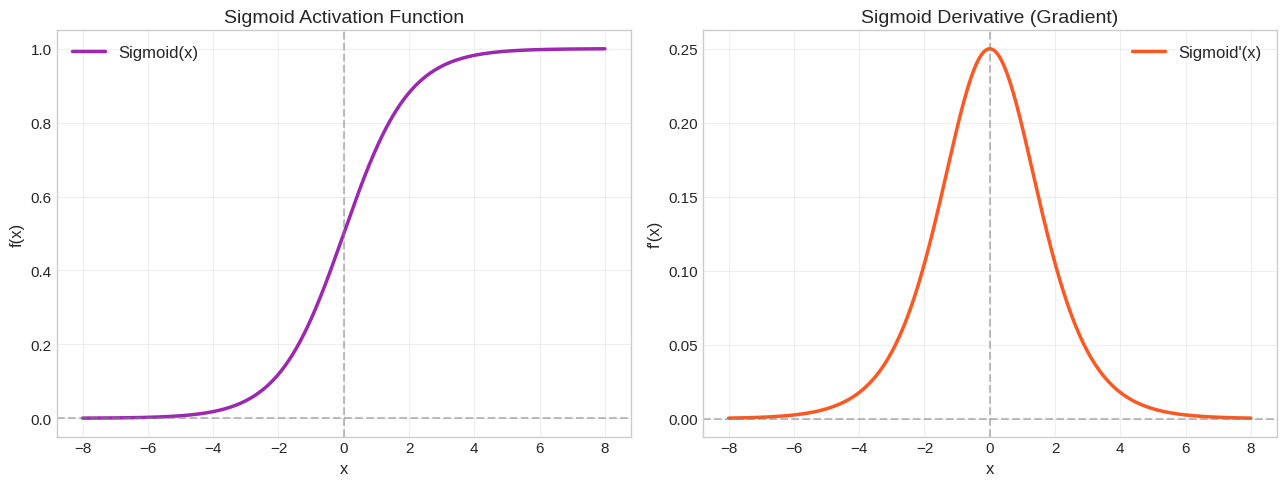

Key Observations:
  • sigmoid(0)  = 0.5000
  • sigmoid(5)  = 0.993307  (saturated → gradient ≈ 0)
  • sigmoid(-5) = 0.006693  (saturated → gradient ≈ 0)
  • Max derivative at x=0: 0.2500
  • Gradient at x=5: 0.00664806

  ⚠️ Vanishing gradient: After 10 layers, gradient decays to ~9.54e-07


In [0]:
# --- Sigmoid Activation Function ---

def sigmoid(x):
    """Sigmoid activation: maps input to (0, 1)."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid: sigma(x) * (1 - sigma(x))."""
    s = sigmoid(x)
    return s * (1 - s)

# Generate data
x = np.linspace(-8, 8, 1000)
y = sigmoid(x)
dy = sigmoid_derivative(x)

# Plot
plot_activation(x, y, dy, 'Sigmoid', color='#9C27B0')

# Key observations
print("Key Observations:")
print(f"  • sigmoid(0)  = {sigmoid(0):.4f}")
print(f"  • sigmoid(5)  = {sigmoid(5):.6f}  (saturated → gradient ≈ 0)")
print(f"  • sigmoid(-5) = {sigmoid(-5):.6f}  (saturated → gradient ≈ 0)")
print(f"  • Max derivative at x=0: {sigmoid_derivative(0):.4f}")
print(f"  • Gradient at x=5: {sigmoid_derivative(5):.8f}")
print(f"\n  ⚠️ Vanishing gradient: After 10 layers, gradient decays to ~{0.25**10:.2e}")

---
## 2. Tanh (Hyperbolic Tangent) Activation Function

### Mathematical Formulation

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} = \frac{2}{1 + e^{-2x}} - 1 = 2\sigma(2x) - 1$$

**Derivative:**

$$\tanh'(x) = 1 - \tanh^2(x)$$

**Output Range:** $$(-1, 1)$$

### Relationship to Sigmoid

Tanh is a scaled and shifted version of the sigmoid:

$$\tanh(x) = 2\sigma(2x) - 1$$

### Properties

- Smooth, continuous, and differentiable everywhere
- **Zero-centered** output — mean of outputs is approximately 0
- Stronger gradients than sigmoid: $$\max(\tanh'(x)) = 1.0$$ at $$x = 0$$
- Still saturates for large $$|x|$$

### Pros

* **Zero-centered**: Unlike sigmoid, outputs are centered around zero, leading to faster convergence (gradients don't systematically push all weights in the same direction)
* **Stronger gradients**: Maximum derivative is 1.0 (vs 0.25 for sigmoid), so gradients flow better
* **Symmetric**: $$\tanh(-x) = -\tanh(x)$$, providing symmetric representation for positive/negative inputs

### Cons

* **Vanishing gradients** (still present): For $$|x| > 3$$, the derivative approaches zero. Better than sigmoid but still problematic in very deep networks
* **Saturation**: Both extremes saturate, killing gradient flow
* **Computationally expensive**: Two exponentials to compute

### When to Use

* **Hidden layers of shallow networks** (1-3 layers) where zero-centering matters
* **RNNs and LSTMs** — tanh is the standard cell state activation
* **Output layer** when outputs should be in $$[-1, 1]$$
* **Normalization contexts** where zero-centered output is crucial
* For deep networks (>5 layers), prefer **ReLU** variants instead

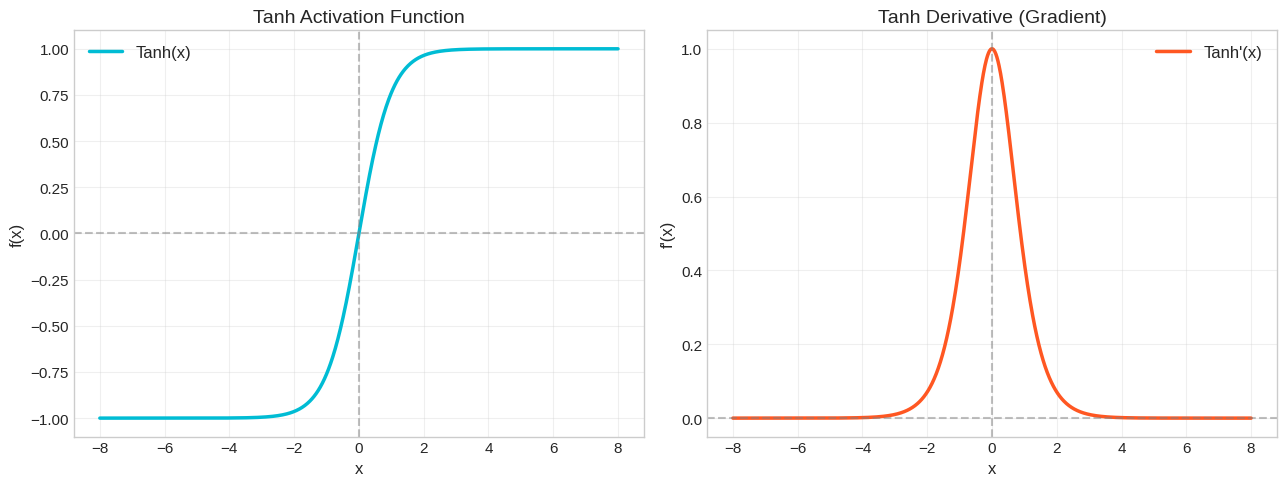

Key Observations:
  • tanh(0) = 0.0000 (zero-centered!)
  • Max derivative at x=0: 1.0000 (4x stronger than sigmoid!)
  • tanh(3) = 0.995055  (approaching saturation)
  • Gradient at x=3: 0.009866
  • Gradient at x=5: 0.00018158 (effectively dead)

  ✅ Advantage over Sigmoid: zero-centered output
  ⚠️ Still suffers from saturation for |x| > 3


In [0]:
# --- Tanh Activation Function ---

def tanh(x):
    """Hyperbolic tangent activation: maps input to (-1, 1)."""
    return np.tanh(x)

def tanh_derivative(x):
    """Derivative of tanh: 1 - tanh^2(x)."""
    return 1 - np.tanh(x)**2

# Generate data
x = np.linspace(-8, 8, 1000)
y = tanh(x)
dy = tanh_derivative(x)

# Plot
plot_activation(x, y, dy, 'Tanh', color='#00BCD4')

# Comparison with sigmoid gradient
print("Key Observations:")
print(f"  • tanh(0) = {tanh(0):.4f} (zero-centered!)")
print(f"  • Max derivative at x=0: {tanh_derivative(0):.4f} (4x stronger than sigmoid!)")
print(f"  • tanh(3) = {tanh(3):.6f}  (approaching saturation)")
print(f"  • Gradient at x=3: {tanh_derivative(3):.6f}")
print(f"  • Gradient at x=5: {tanh_derivative(5):.8f} (effectively dead)")
print(f"\n  ✅ Advantage over Sigmoid: zero-centered output")
print(f"  ⚠️ Still suffers from saturation for |x| > 3")

---
## 3. ReLU (Rectified Linear Unit)

### Mathematical Formulation

$$\text{ReLU}(x) = \max(0, x) = \begin{cases} x & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

**Derivative:**

$$\text{ReLU}'(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x < 0 \\ \text{undefined} & \text{if } x = 0 \end{cases}$$

(In practice, the sub-gradient at $$x = 0$$ is set to 0 or 0.5)

**Output Range:** $$[0, \infty)$$

### The Breakthrough

ReLU was the key innovation that enabled training of **deep networks** (Krizhevsky et al., 2012 — AlexNet). It solved the vanishing gradient problem for positive activations.

### Pros

* **No vanishing gradient** (for positive inputs): Gradient is exactly 1 for $$x > 0$$, enabling deep gradient flow
* **Computational efficiency**: Only a threshold comparison — no exponentials! \~6x faster than sigmoid/tanh
* **Sparsity**: Approximately 50% of neurons output zero, creating sparse representations (biological plausibility + regularization effect)
* **Linear for positive inputs**: Avoids the saturation regime entirely for $$x > 0$$
* **Convergence speed**: Networks with ReLU converge \~6x faster than with tanh (Krizhevsky, 2012)

### Cons

* **Dying ReLU Problem** (Critical): If a neuron's input is always negative (due to large negative bias or weights), its gradient is **permanently zero**. The neuron is effectively dead and will never activate again. This can happen to 10-40% of neurons during training.
* **Not zero-centered**: Output is always $$\geq 0$$, causing same zig-zag gradient issue as sigmoid
* **Unbounded output**: Can cause exploding activations if not properly initialized or regularized
* **Not differentiable at x=0**: Technically a concern, but negligible in practice

### The Dying ReLU Problem in Detail

A neuron dies when:

$$W \cdot x + b < 0 \quad \text{for ALL training samples}$$

This can happen due to:
1. Large learning rate causing dramatic weight updates
2. Poor initialization (large negative biases)
3. High learning rate + data distribution shift

Once dead: $$\nabla_W \text{ReLU}(Wx + b) = 0$$ → no gradient → no recovery.

### When to Use

* **Default choice for hidden layers** in most feedforward and convolutional networks
* **CNNs**: Standard activation for all convolutional and dense layers
* **Any deep network** where computational efficiency matters
* Use with **careful initialization** (He initialization: $$W \sim \mathcal{N}(0, \sqrt{2/n_{\text{in}}})$$)
* Consider Leaky ReLU if you observe many dead neurons

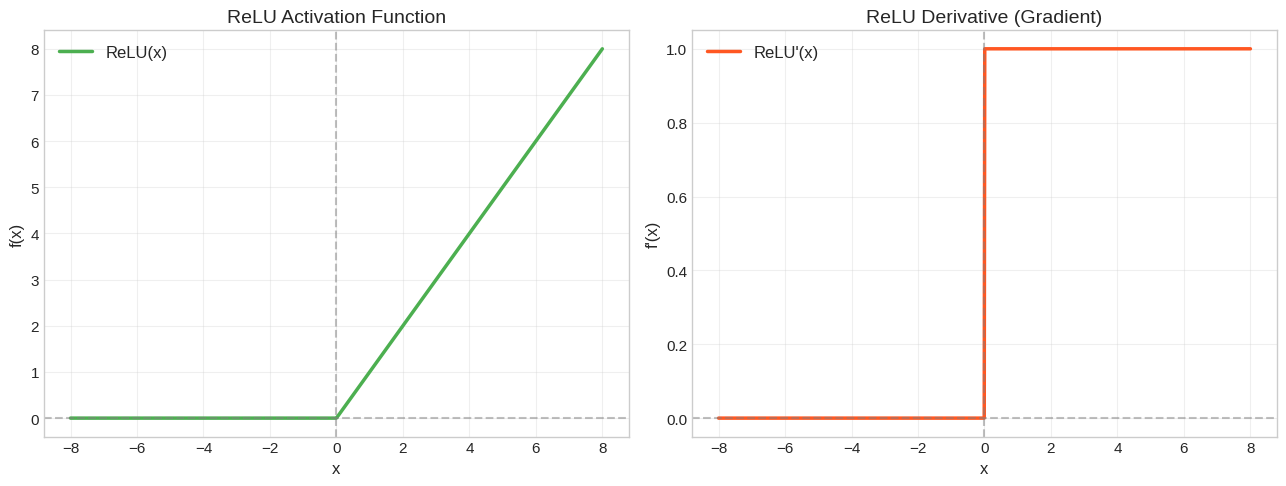

Key Observations:
  • ReLU(2) = 2.0  | ReLU'(2) = 1.0 (perfect gradient flow!)
  • ReLU(-2) = 0.0 | ReLU'(-2) = 0.0 (DEAD - zero gradient!)
  • ReLU(0) = 0.0  | ReLU'(0) = 0.0

  ✅ No vanishing gradient for x > 0
  ⚠️ Dying ReLU: ~40% of neurons can die with high learning rates
  💡 Use He initialization: W ~ N(0, sqrt(2/fan_in))


In [0]:
# --- ReLU Activation Function ---

def relu(x):
    """Rectified Linear Unit: max(0, x)."""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU: 1 if x > 0, else 0."""
    return np.where(x > 0, 1.0, 0.0)

# Generate data
x = np.linspace(-8, 8, 1000)
y = relu(x)
dy = relu_derivative(x)

# Plot
plot_activation(x, y, dy, 'ReLU', color='#4CAF50')

# Demonstrate dying ReLU
print("Key Observations:")
print(f"  • ReLU(2) = {relu(2):.1f}  | ReLU'(2) = {relu_derivative(2):.1f} (perfect gradient flow!)")
print(f"  • ReLU(-2) = {relu(-2):.1f} | ReLU'(-2) = {relu_derivative(-2):.1f} (DEAD - zero gradient!)")
print(f"  • ReLU(0) = {relu(0):.1f}  | ReLU'(0) = {relu_derivative(0):.1f}")
print(f"\n  ✅ No vanishing gradient for x > 0")
print(f"  ⚠️ Dying ReLU: ~40% of neurons can die with high learning rates")
print(f"  💡 Use He initialization: W ~ N(0, sqrt(2/fan_in))")

---
## 4. Leaky ReLU (and Parametric ReLU)

### Mathematical Formulation

$$\text{LeakyReLU}(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha x & \text{if } x \leq 0 \end{cases} = \max(\alpha x, x)$$

where $$\alpha$$ is a small constant (typically 0.01).

**Derivative:**

$$\text{LeakyReLU}'(x) = \begin{cases} 1 & \text{if } x > 0 \\ \alpha & \text{if } x \leq 0 \end{cases}$$

**Output Range:** $$(-\infty, \infty)$$

### Variants

| Variant | $$\alpha$$ | Description |
| --- | --- | --- |
| Leaky ReLU | 0.01 (fixed) | Small fixed slope for negative inputs |
| Parametric ReLU (PReLU) | Learned | $$\alpha$$ is a trainable parameter |
| Randomized Leaky ReLU (RReLU) | Random in training | $$\alpha \sim U(l, u)$$ during training, averaged at test |

### Pros

* **No dying neurons**: The non-zero slope $$\alpha$$ ensures gradients never become permanently zero — neurons can always recover
* **Preserves ReLU efficiency**: Still computationally simple (one multiplication for negative side)
* **Better gradient flow**: Small gradient for negative inputs keeps learning possible in all neurons
* **No saturation**: Neither the positive nor negative branch saturates

### Cons

* **Hyperparameter sensitivity**: The choice of $$\alpha$$ matters. Too small (0.001) ≈ ReLU; too large (0.5) ≈ linear
* **Not zero-centered** (unless $$\alpha = 1$$, which makes it linear)
* **Inconsistent literature**: Some studies show marginal improvement over ReLU, others show significant gains — depends on architecture and data
* **PReLU adds parameters**: Each neuron has an extra learnable parameter, slightly increasing model size

### When to Use

* **When dying ReLU is observed**: Monitor the fraction of dead neurons; switch to Leaky ReLU if >20% are inactive
* **Generative models** (GANs): The discriminator benefits from non-zero gradients everywhere
* **Very deep networks** where some neurons receiving only negative inputs is likely
* **PReLU** is preferred when you have enough data to learn $$\alpha$$ reliably (avoids manual tuning)

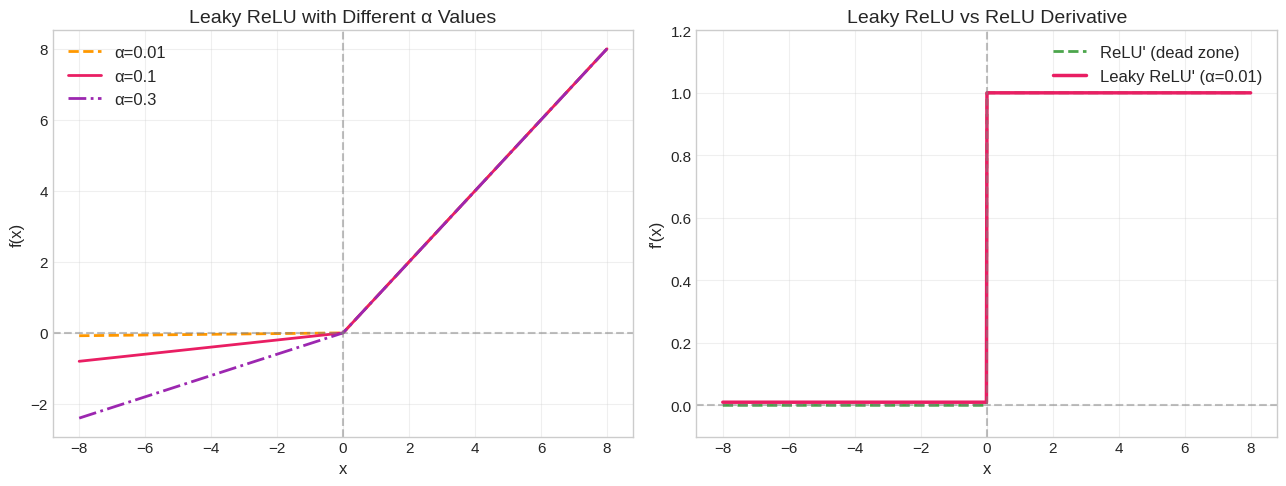

Key Observations:
  • LeakyReLU(-5, α=0.01) = -0.05 (small but non-zero!)
  • Gradient for x<0: 0.01 (never zero → no dying neurons)
  • ReLU gradient for x<0: 0.0 (dead!)

  ✅ Solves the dying ReLU problem
  💡 Use PReLU to let the network learn optimal α


In [0]:
# --- Leaky ReLU Activation Function ---

def leaky_relu(x, alpha=0.01):
    """Leaky ReLU: allows small gradient for negative inputs."""
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    """Derivative of Leaky ReLU."""
    return np.where(x > 0, 1.0, alpha)

# Generate data
x = np.linspace(-8, 8, 1000)
alpha = 0.1  # Using 0.1 for visibility in plot
y = leaky_relu(x, alpha)
dy = leaky_relu_derivative(x, alpha)

# Plot with visible slope
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Show multiple alpha values
for a, color, ls in [(0.01, '#FF9800', '--'), (0.1, '#E91E63', '-'), (0.3, '#9C27B0', '-.')]: 
    y_a = leaky_relu(x, a)
    ax1.plot(x, y_a, color=color, linewidth=2, label=f'α={a}', linestyle=ls)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Leaky ReLU with Different α Values')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Compare gradient with ReLU
ax2.plot(x, relu_derivative(x), 'g--', linewidth=2, alpha=0.7, label="ReLU' (dead zone)")
ax2.plot(x, leaky_relu_derivative(x, 0.01), color='#E91E63', linewidth=2.5, label="Leaky ReLU' (α=0.01)")
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.set_title('Leaky ReLU vs ReLU Derivative')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.1, 1.2)

plt.tight_layout()
plt.show()

print("Key Observations:")
print(f"  • LeakyReLU(-5, α=0.01) = {leaky_relu(-5, 0.01):.2f} (small but non-zero!)")
print(f"  • Gradient for x<0: {0.01} (never zero → no dying neurons)")
print(f"  • ReLU gradient for x<0: 0.0 (dead!)")
print(f"\n  ✅ Solves the dying ReLU problem")
print(f"  💡 Use PReLU to let the network learn optimal α")

---
## 5. ELU (Exponential Linear Unit)

### Mathematical Formulation

$$\text{ELU}(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha(e^x - 1) & \text{if } x \leq 0 \end{cases}$$

where $$\alpha > 0$$ (typically $$\alpha = 1.0$$).

**Derivative:**

$$\text{ELU}'(x) = \begin{cases} 1 & \text{if } x > 0 \\ \text{ELU}(x) + \alpha & \text{if } x \leq 0 \end{cases} = \begin{cases} 1 & \text{if } x > 0 \\ \alpha e^x & \text{if } x \leq 0 \end{cases}$$

**Output Range:** $$[-\alpha, \infty)$$

### Key Innovation

ELU (Clevert et al., 2016) combines the best of both worlds:
- Like ReLU: no vanishing gradient for $$x > 0$$
- Like tanh: **approximately zero-centered** (negative values push mean activation toward zero)
- Smooth: continuously differentiable everywhere (unlike ReLU's kink at 0)

### Pros

* **Zero-centered outputs**: Negative values allow mean activations closer to zero, speeding up learning
* **No dying neurons**: Gradient is never permanently zero (approaches $$\alpha e^x$$ for negative $$x$$)
* **Smooth**: Unlike ReLU/Leaky ReLU, ELU is smooth at $$x = 0$$, which can help optimization
* **Noise robustness**: The saturation for large negative values (approaching $$-\alpha$$) makes ELU more robust to noise
* **Faster convergence** than ReLU in some deep architectures due to zero-centering

### Cons

* **Computationally expensive**: Requires exponential computation for $$x < 0$$ (slower than ReLU)
* **Saturates for large negative inputs**: While not as severe as sigmoid, very negative inputs still have diminishing gradients
* **Hyperparameter $$\alpha$$**: Needs tuning (though $$\alpha = 1.0$$ works well in most cases)
* **Not monotonic derivative**: The derivative has a discontinuity in its own derivative (2nd derivative)

### When to Use

* **Deep feedforward networks** where zero-centered activations and noise robustness matter
* **Autoencoders** and generative models where reconstruction quality benefits from smoother activations
* **When batch normalization is not used** (ELU's zero-centering partially compensates)
* **Networks sensitive to noise** in the input data

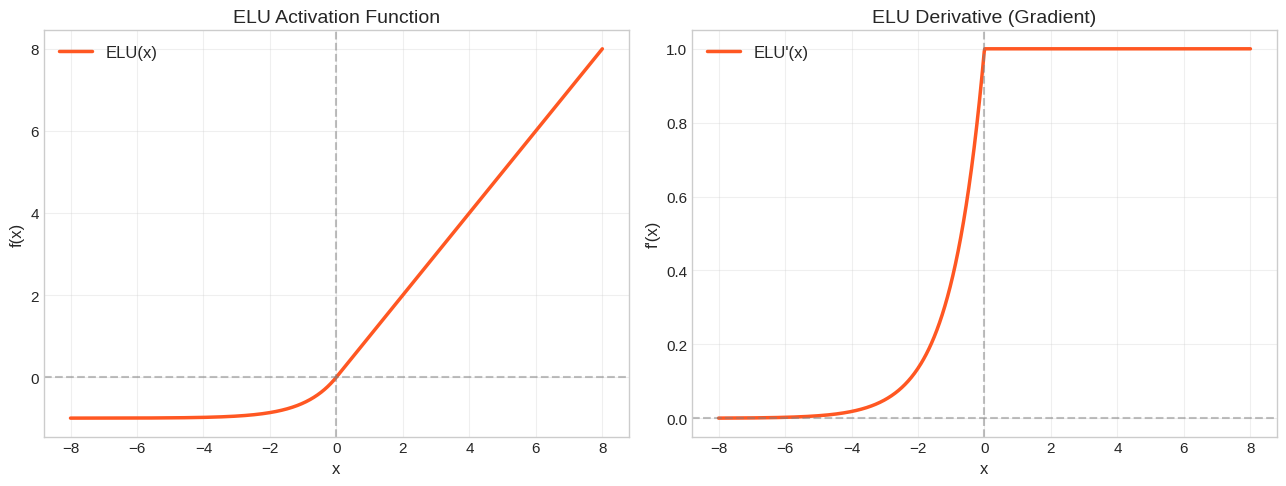

Key Observations:
  • ELU(-∞) → -1.0000 ≈ -α = -1.0 (bounded below)
  • ELU(0) = 0.0000
  • ELU'(0⁻) = 0.9990 (smooth transition!)
  • ELU'(0⁺) = 1.0000
  • Mean of ELU outputs (uniform input): 0.4150 (≈ zero-centered)

  ✅ Smooth + zero-centered + no dying neurons
  ⚠️ Slower than ReLU due to exp() computation


In [0]:
# --- ELU Activation Function ---

def elu(x, alpha=1.0):
    """Exponential Linear Unit."""
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_derivative(x, alpha=1.0):
    """Derivative of ELU."""
    return np.where(x > 0, 1.0, alpha * np.exp(x))

# Generate data
x = np.linspace(-8, 8, 1000)
y = elu(x)
dy = elu_derivative(x)

# Plot
plot_activation(x, y, dy, 'ELU', color='#FF5722')

# Show zero-centering property
print("Key Observations:")
print(f"  • ELU(-∞) → {1.0 * (np.exp(-10) - 1):.4f} ≈ -α = -1.0 (bounded below)")
print(f"  • ELU(0) = {elu(0):.4f}")
print(f"  • ELU'(0⁻) = {elu_derivative(-0.001):.4f} (smooth transition!)")
print(f"  • ELU'(0⁺) = {elu_derivative(0.001):.4f}")
print(f"  • Mean of ELU outputs (uniform input): {np.mean(elu(np.random.uniform(-3, 3, 10000))):.4f} (≈ zero-centered)")
print(f"\n  ✅ Smooth + zero-centered + no dying neurons")
print(f"  ⚠️ Slower than ReLU due to exp() computation")

---
## 6. SELU (Scaled Exponential Linear Unit)

### Mathematical Formulation

$$\text{SELU}(x) = \lambda \begin{cases} x & \text{if } x > 0 \\ \alpha(e^x - 1) & \text{if } x \leq 0 \end{cases}$$

with specific constants:
$$\lambda \approx 1.0507 \qquad \alpha \approx 1.6733$$

These values are derived analytically to ensure **self-normalizing** properties.

**Derivative:**

$$\text{SELU}'(x) = \lambda \begin{cases} 1 & \text{if } x > 0 \\ \alpha e^x & \text{if } x \leq 0 \end{cases}$$

**Output Range:** $$[-\lambda\alpha, \infty) \approx [-1.7581, \infty)$$

### The Self-Normalizing Property

SELU (Klambauer et al., 2017) is mathematically designed so that for networks with:
- SELU activations in all hidden layers
- Lecun Normal initialization: $$W \sim \mathcal{N}(0, 1/n_{\text{in}})$$
- Sequential (feedforward) architecture

The activations **automatically converge** to zero mean and unit variance:

$$\mu \to 0, \quad \sigma^2 \to 1$$

This is **Self-Normalizing Neural Networks** (SNNs) — they don't need Batch Normalization!

### Pros

* **Self-normalizing**: Activations automatically maintain mean≈0 and variance≈1 without BatchNorm
* **No vanishing/exploding gradients**: The normalization prevents both pathologies
* **Theoretically grounded**: Derived from fixed-point theory with provable convergence
* **Internal regularization**: The self-normalizing property acts as implicit regularization

### Cons

* **Strict architecture requirements**: Only works correctly with:
  - Fully-connected (dense) layers only
  - Sequential architecture (no skip connections!)
  - Lecun Normal initialization
  - AlphaDropout (not standard Dropout)
* **Not suitable for CNNs or ResNets**: Skip connections break the self-normalizing property
* **Sensitive to violations**: If any condition is violated, SELU offers no advantage over ELU
* **Limited applicability**: Modern architectures (Transformers, ResNets) cannot use SELU effectively

### When to Use

* **Deep fully-connected networks** (e.g., tabular data with 10+ dense layers)
* **When you cannot use Batch Normalization** for some reason
* **Tabular data problems** where MLPs are preferred over tree models
* **NOT for CNNs, ResNets, Transformers, or any architecture with skip connections**

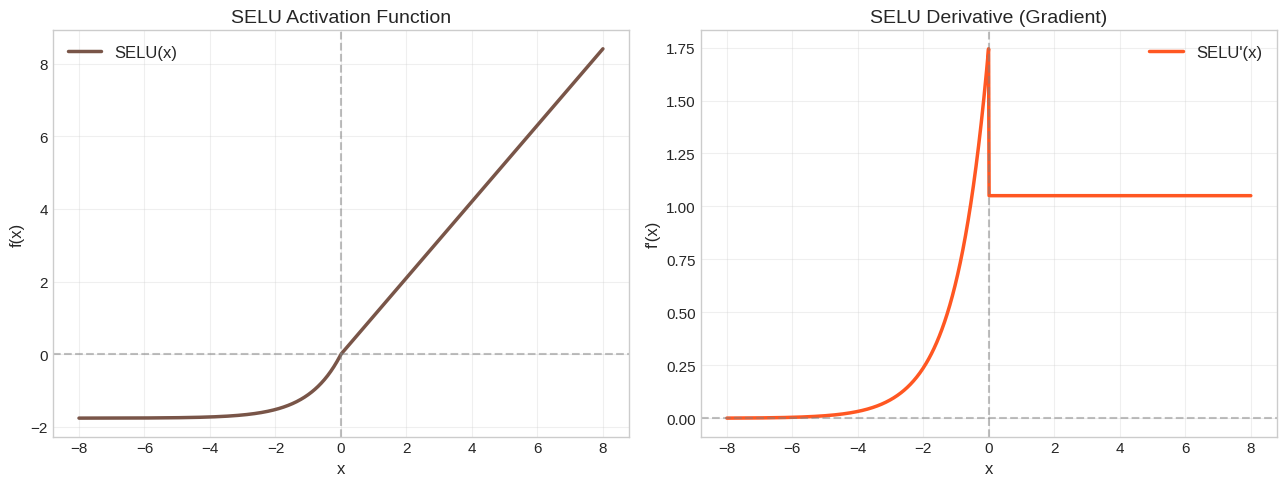

Demonstrating Self-Normalizing Property:
  After 20 layers:
  • Mean of activations: -0.002707 (≈ 0 ✓)
  • Std of activations:  1.000629 (≈ 1 ✓)

  ✅ Self-normalizing: no BatchNorm needed!
  ⚠️ Only works with dense layers + Lecun init + no skip connections


In [0]:
# --- SELU Activation Function ---

# Analytically derived constants for self-normalizing property
SELU_LAMBDA = 1.0507009873554804934193349852946
SELU_ALPHA = 1.6732632423543772848170429916717

def selu(x):
    """Scaled ELU with self-normalizing constants."""
    return SELU_LAMBDA * np.where(x > 0, x, SELU_ALPHA * (np.exp(x) - 1))

def selu_derivative(x):
    """Derivative of SELU."""
    return SELU_LAMBDA * np.where(x > 0, 1.0, SELU_ALPHA * np.exp(x))

# Generate data
x = np.linspace(-8, 8, 1000)
y = selu(x)
dy = selu_derivative(x)

# Plot
plot_activation(x, y, dy, 'SELU', color='#795548')

# Demonstrate self-normalizing property
np.random.seed(42)
print("Demonstrating Self-Normalizing Property:")
print("="*50)

# Simulate a deep network with SELU
n_layers = 20
n_neurons = 256
activations = np.random.randn(1000, n_neurons)  # Input batch

for layer in range(n_layers):
    # Lecun Normal initialization
    W = np.random.randn(n_neurons, n_neurons) / np.sqrt(n_neurons)
    activations = selu(activations @ W)

print(f"  After {n_layers} layers:")
print(f"  • Mean of activations: {np.mean(activations):.6f} (≈ 0 ✓)")
print(f"  • Std of activations:  {np.std(activations):.6f} (≈ 1 ✓)")
print(f"\n  ✅ Self-normalizing: no BatchNorm needed!")
print(f"  ⚠️ Only works with dense layers + Lecun init + no skip connections")

---
## 7. Swish / SiLU (Sigmoid Linear Unit)

### Mathematical Formulation

$$\text{Swish}(x) = x \cdot \sigma(\beta x) = \frac{x}{1 + e^{-\beta x}}$$

where $$\beta$$ is a learnable parameter or constant (typically $$\beta = 1$$).

When $$\beta = 1$$, it is called **SiLU** (Sigmoid Linear Unit):

$$\text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

**Derivative:**

$$\text{Swish}'(x) = \sigma(x) + x \cdot \sigma(x) \cdot (1 - \sigma(x)) = \sigma(x)(1 + x(1 - \sigma(x)))$$

Or more compactly:

$$\text{Swish}'(x) = \text{Swish}(x) + \sigma(x)(1 - \text{Swish}(x))$$

**Output Range:** $$[\approx -0.278, \infty)$$

### Key Innovation

Swish (Ramachandran et al., 2017, Google Brain) was discovered through **automated search** over activation function space. It is a **self-gated** activation — the input $$x$$ is modulated by a gate $$\sigma(x)$$.

### Properties

- **Non-monotonic**: Has a small dip below zero near $$x \approx -1.28$$
- **Smooth**: Infinitely differentiable (no kinks)
- **Unbounded above, bounded below**: $$\min(\text{Swish}(x)) \approx -0.278$$
- **Self-gating**: $$\sigma(x)$$ acts as a soft gate controlling information flow

### Behavior Interpolation

| $$\beta$$ value | Behavior |
| --- | --- |
| $$\beta \to 0$$ | Linear function $$f(x) = x/2$$ |
| $$\beta = 1$$ | SiLU (standard Swish) |
| $$\beta \to \infty$$ | Approaches ReLU |

### Pros

* **Outperforms ReLU** on deep networks (40+ layers) in many benchmarks
* **Smooth**: Better optimization landscape than ReLU
* **Non-monotonicity**: The small negative region acts as a form of implicit regularization (allows small negative outputs, adding expressiveness)
* **No dying neurons**: Gradient is never permanently zero
* **Self-gating**: Elegant information flow control without additional parameters

### Cons

* **Computationally more expensive** than ReLU (requires sigmoid computation)
* **Marginal improvement on shallow networks**: Benefits mainly appear in deep architectures
* **Non-intuitive**: The non-monotonic behavior is harder to reason about
* **Memory**: Requires storing intermediate sigmoid values for backprop

### When to Use

* **Deep CNNs** (EfficientNet, MobileNetV3 use Swish as default)
* **NLP models** and Transformer-based architectures
* **Any architecture >20 layers** where marginal accuracy gains matter
* **As a drop-in replacement for ReLU** when computational budget allows
* **EfficientNet family**: All EfficientNet models use Swish/SiLU

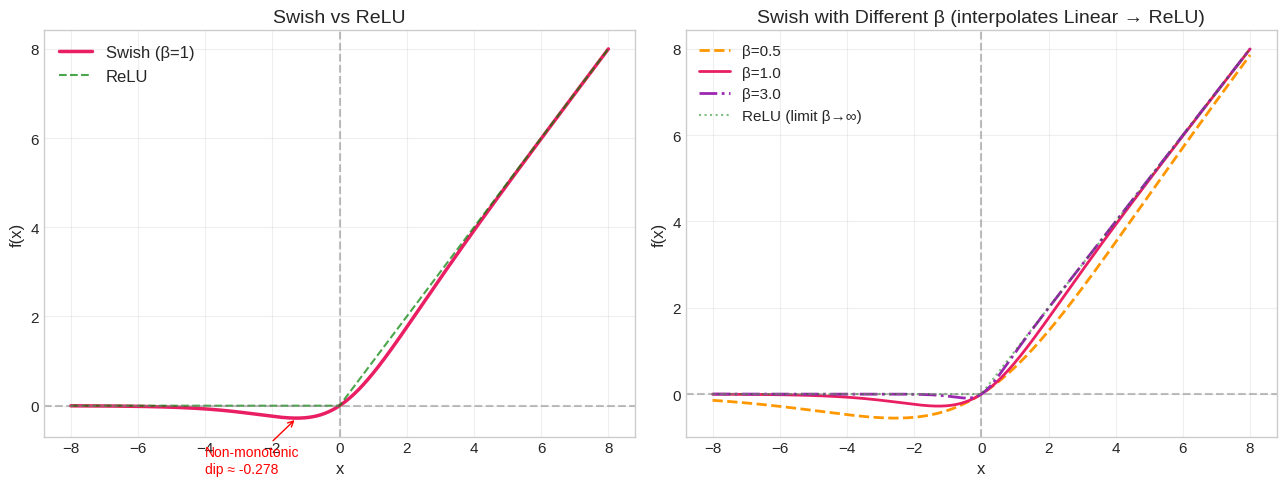

Key Observations:
  • Swish(-1.28) = -0.2785 (non-monotonic dip!)
  • Min value of Swish ≈ -0.2785
  • Swish'(0) = 0.5000
  • Smooth everywhere (unlike ReLU at x=0)

  ✅ Used in EfficientNet, MobileNetV3
  ✅ Outperforms ReLU in deep networks


In [0]:
# --- Swish / SiLU Activation Function ---

def swish(x, beta=1.0):
    """Swish activation: x * sigmoid(beta * x)."""
    return x * sigmoid(beta * x)

def swish_derivative(x, beta=1.0):
    """Derivative of Swish."""
    s = sigmoid(beta * x)
    return s + beta * x * s * (1 - s)

# Generate data
x = np.linspace(-8, 8, 1000)
y = swish(x)
dy = swish_derivative(x)

# Plot showing non-monotonic behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Show Swish vs ReLU comparison
ax1.plot(x, swish(x), color='#E91E63', linewidth=2.5, label='Swish (β=1)')
ax1.plot(x, relu(x), 'g--', linewidth=1.5, alpha=0.7, label='ReLU')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Highlight the non-monotonic dip
ax1.annotate('Non-monotonic\ndip ≈ -0.278', xy=(-1.28, swish(-1.28)),
            xytext=(-4, -1.5), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red')

ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Swish vs ReLU')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Show different beta values
for beta, color, ls in [(0.5, '#FF9800', '--'), (1.0, '#E91E63', '-'), (3.0, '#9C27B0', '-.')]:
    ax2.plot(x, swish(x, beta), color=color, linewidth=2, label=f'β={beta}', linestyle=ls)
ax2.plot(x, relu(x), 'g:', linewidth=1.5, alpha=0.5, label='ReLU (limit β→∞)')

ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Swish with Different β (interpolates Linear → ReLU)')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print(f"  • Swish(-1.28) = {swish(-1.28):.4f} (non-monotonic dip!)")
print(f"  • Min value of Swish ≈ {min(swish(x)):.4f}")
print(f"  • Swish'(0) = {swish_derivative(0):.4f}")
print(f"  • Smooth everywhere (unlike ReLU at x=0)")
print(f"\n  ✅ Used in EfficientNet, MobileNetV3")
print(f"  ✅ Outperforms ReLU in deep networks")

---
## 8. GELU (Gaussian Error Linear Unit)

### Mathematical Formulation

$$\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$$

where $$\Phi(x)$$ is the CDF of the standard normal distribution.

**Approximation** (commonly used in practice):

$$\text{GELU}(x) \approx 0.5x\left[1 + \tanh\left(\sqrt{\frac{2}{\pi}}(x + 0.044715x^3)\right)\right]$$

**Derivative:**

$$\text{GELU}'(x) = \Phi(x) + x \cdot \phi(x)$$

where $$\phi(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$$ is the standard normal PDF.

**Output Range:** $$[\approx -0.17, \infty)$$

### Key Innovation

GELU (Hendrycks & Gimpel, 2016) provides a **stochastic interpretation**: it multiplies the input by a Bernoulli mask where the probability of keeping a value depends on its magnitude. Larger inputs are more likely to be kept.

$$\text{GELU}(x) = x \cdot P(X \leq x) \quad \text{where } X \sim \mathcal{N}(0, 1)$$

This is a **smooth, deterministic analog of dropout** — small activations are probabilistically zeroed.

### Pros

* **State-of-the-art in NLP**: Default activation in BERT, GPT-2/3/4, RoBERTa, ALBERT, and most modern Transformers
* **Smooth**: Infinitely differentiable, better optimization landscape
* **Stochastic regularization**: The probabilistic zeroing acts as built-in regularization
* **Non-monotonic**: Like Swish, the small dip provides expressiveness
* **Theoretically motivated**: Bridges activation functions and dropout theory

### Cons

* **Computationally expensive**: Requires error function (erf) or its approximation
* **Complex derivative**: More complex backpropagation than ReLU
* **Approximation needed**: Exact form uses erf; practical implementations use tanh approximation
* **Marginal gains outside NLP**: In vision tasks, Swish and ReLU often perform comparably

### When to Use

* **Transformers**: BERT, GPT, and virtually all modern language models
* **NLP tasks**: Text classification, NER, machine translation, etc.
* **Vision Transformers (ViT)**: GELU is the standard activation
* **Any attention-based architecture**
* Essentially: **if you're using a Transformer, use GELU**

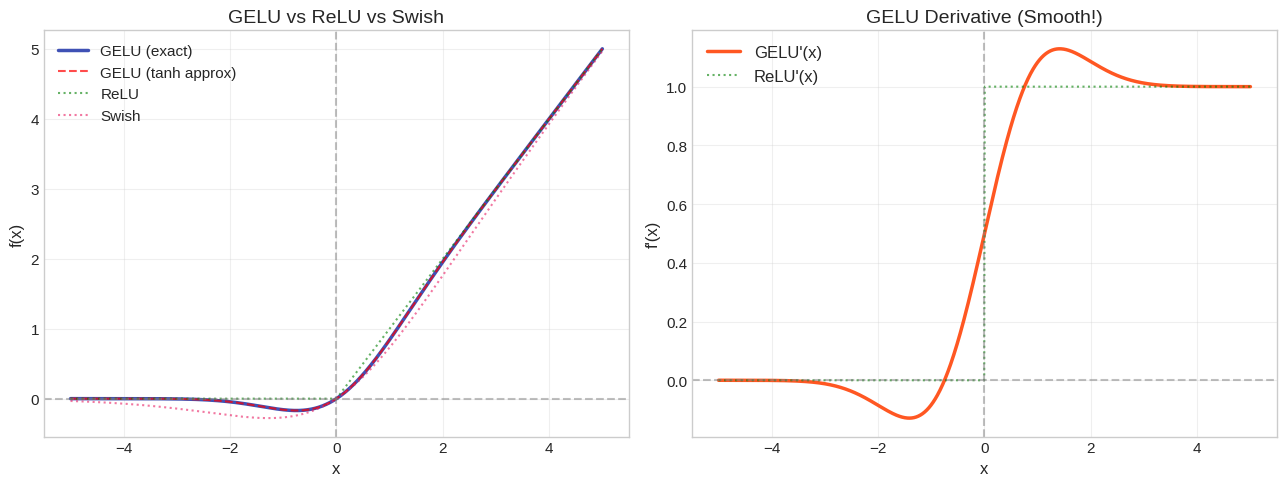

Key Observations:
  • Max error of tanh approximation: 0.000473 (excellent!)
  • GELU(0) = 0.0000
  • GELU'(0) = 0.5000
  • Min value of GELU ≈ -0.1700

  ✅ Default for Transformers: BERT, GPT, ViT
  💡 Stochastic interpretation: smooth dropout analog


In [0]:
# --- GELU Activation Function ---
from scipy.special import erf
from scipy.stats import norm

def gelu_exact(x):
    """Exact GELU using the error function."""
    return 0.5 * x * (1 + erf(x / np.sqrt(2)))

def gelu_approx(x):
    """Tanh approximation of GELU (used in practice)."""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

def gelu_derivative(x):
    """Derivative of GELU."""
    phi = norm.cdf(x)  # CDF of standard normal
    pdf = norm.pdf(x)  # PDF of standard normal
    return phi + x * pdf

# Generate data
x = np.linspace(-5, 5, 1000)
y_exact = gelu_exact(x)
y_approx = gelu_approx(x)
dy = gelu_derivative(x)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# GELU vs ReLU vs Swish
ax1.plot(x, y_exact, color='#3F51B5', linewidth=2.5, label='GELU (exact)')
ax1.plot(x, y_approx, 'r--', linewidth=1.5, alpha=0.7, label='GELU (tanh approx)')
ax1.plot(x, relu(x), 'g:', linewidth=1.5, alpha=0.6, label='ReLU')
ax1.plot(x, swish(x), color='#E91E63', linestyle=':', linewidth=1.5, alpha=0.6, label='Swish')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('GELU vs ReLU vs Swish')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Derivative
ax2.plot(x, dy, color='#FF5722', linewidth=2.5, label="GELU'(x)")
ax2.plot(x, relu_derivative(x), 'g:', linewidth=1.5, alpha=0.6, label="ReLU'(x)")
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.set_title('GELU Derivative (Smooth!)')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify approximation accuracy
max_error = np.max(np.abs(y_exact - y_approx))
print(f"Key Observations:")
print(f"  • Max error of tanh approximation: {max_error:.6f} (excellent!)")
print(f"  • GELU(0) = {gelu_exact(0):.4f}")
print(f"  • GELU'(0) = {gelu_derivative(0):.4f}")
print(f"  • Min value of GELU ≈ {min(y_exact):.4f}")
print(f"\n  ✅ Default for Transformers: BERT, GPT, ViT")
print(f"  💡 Stochastic interpretation: smooth dropout analog")

---
## 9. Mish Activation Function

### Mathematical Formulation

$$\text{Mish}(x) = x \cdot \tanh(\text{softplus}(x)) = x \cdot \tanh(\ln(1 + e^x))$$

**Derivative:**

$$\text{Mish}'(x) = \frac{e^x \cdot \omega}{\delta^2}$$

where:
$$\omega = 4(x + 1) + 4e^{2x} + e^{3x} + e^x(4x + 6)$$
$$\delta = 2e^x + e^{2x} + 2$$

Or more practically:

$$\text{Mish}'(x) = \text{sech}^2(\text{softplus}(x)) \cdot \sigma(x) + \frac{\text{Mish}(x)}{x}$$

**Output Range:** $$[\approx -0.3068, \infty)$$

### Key Innovation

Mish (Misra, 2019) is a **self-regularizing, non-monotonic** activation function that:
- Uses $$\text{softplus}(x) = \ln(1 + e^x)$$ as a smooth approximation of ReLU
- Applies tanh to bound the softplus, then self-gates with $$x$$
- Creates a deeper negative dip than Swish (≈0.31 vs ≈0.28)

### Pros

* **Outperforms Swish and ReLU** on several vision benchmarks (YOLOv4, CSPNet)
* **Smooth and non-monotonic**: Similar benefits to Swish but with slightly different curvature
* **Self-regularizing**: The non-monotonic region acts as implicit regularization
* **Unbounded above**: No saturation for positive inputs
* **Preserves small negative values**: The dip below zero provides information flow for slightly negative pre-activations

### Cons

* **Most computationally expensive**: Requires softplus + tanh + multiplication
* **Complex derivative**: Backpropagation is more involved
* **Marginal gains**: Improvements over Swish are often <1% accuracy
* **Less studied**: Fewer theoretical guarantees compared to GELU or SELU

### When to Use

* **Object detection** (YOLOv4, YOLOv5 use Mish in the backbone)
* **Deep CNNs** for computer vision where maximum accuracy is the goal
* **When Swish performs well but you want to squeeze out more performance**
* **CSPNet and DarkNet architectures**

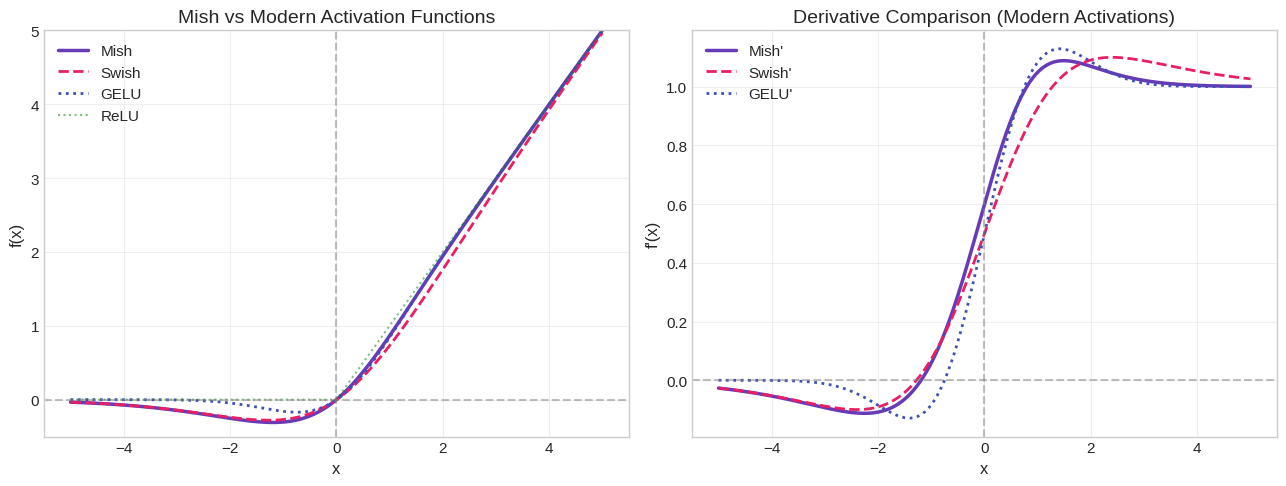

Key Observations:
  • Mish minimum ≈ -0.3088 (deeper dip than Swish's -0.2785)
  • Mish(0) = 0.0000
  • Mish'(0) = 0.6000

  ✅ Used in YOLOv4/v5 for object detection
  ⚠️ Most computationally expensive activation


In [0]:
# --- Mish Activation Function ---

def softplus(x):
    """Softplus: smooth approximation of ReLU."""
    return np.log1p(np.exp(x))

def mish(x):
    """Mish activation: x * tanh(softplus(x))."""
    return x * np.tanh(softplus(x))

def mish_derivative(x):
    """Numerical derivative of Mish."""
    sp = softplus(x)
    tanh_sp = np.tanh(sp)
    sech2_sp = 1 - tanh_sp**2
    sig = sigmoid(x)
    return tanh_sp + x * sech2_sp * sig

# Generate data
x = np.linspace(-5, 5, 1000)
y = mish(x)
dy = mish_derivative(x)

# Plot comparison of modern activations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Mish vs Swish vs GELU vs ReLU
ax1.plot(x, mish(x), color='#673AB7', linewidth=2.5, label='Mish')
ax1.plot(x, swish(x), color='#E91E63', linewidth=2, linestyle='--', label='Swish')
ax1.plot(x, gelu_exact(x), color='#3F51B5', linewidth=2, linestyle=':', label='GELU')
ax1.plot(x, relu(x), 'g:', linewidth=1.5, alpha=0.5, label='ReLU')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Mish vs Modern Activation Functions')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.5, 5)

# Derivatives comparison
ax2.plot(x, mish_derivative(x), color='#673AB7', linewidth=2.5, label="Mish'")
ax2.plot(x, swish_derivative(x), color='#E91E63', linewidth=2, linestyle='--', label="Swish'")
ax2.plot(x, gelu_derivative(x), color='#3F51B5', linewidth=2, linestyle=':', label="GELU'")
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.set_title('Derivative Comparison (Modern Activations)')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print(f"  • Mish minimum ≈ {min(y):.4f} (deeper dip than Swish's {min(swish(x)):.4f})")
print(f"  • Mish(0) = {mish(0):.4f}")
print(f"  • Mish'(0) = {mish_derivative(0):.4f}")
print(f"\n  ✅ Used in YOLOv4/v5 for object detection")
print(f"  ⚠️ Most computationally expensive activation")

---
## 10. Softmax Activation Function

### Mathematical Formulation

For a vector $$\mathbf{z} = [z_1, z_2, \ldots, z_K]$$:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad \text{for } i = 1, \ldots, K$$

**Properties:**
- $$\sum_{i=1}^{K} \text{Softmax}(z_i) = 1$$ (forms a probability distribution)
- $$\text{Softmax}(z_i) \in (0, 1)$$ for all $$i$$

**Jacobian** (not a simple derivative since output depends on all inputs):

$$\frac{\partial \text{Softmax}(z_i)}{\partial z_j} = \begin{cases} \text{Softmax}(z_i)(1 - \text{Softmax}(z_i)) & \text{if } i = j \\ -\text{Softmax}(z_i) \cdot \text{Softmax}(z_j) & \text{if } i \neq j \end{cases}$$

Or in matrix form:
$$J = \text{diag}(\mathbf{s}) - \mathbf{s}\mathbf{s}^T$$

where $$\mathbf{s} = \text{Softmax}(\mathbf{z})$$.

### Numerical Stability

Naive implementation can overflow for large $$z_i$$. The standard trick:

$$\text{Softmax}(z_i) = \frac{e^{z_i - \max(\mathbf{z})}}{\sum_{j=1}^{K} e^{z_j - \max(\mathbf{z})}}$$

Subtracting $$\max(\mathbf{z})$$ doesn't change the result but prevents overflow.

### Temperature Scaling

$$\text{Softmax}_T(z_i) = \frac{e^{z_i/T}}{\sum_{j=1}^{K} e^{z_j/T}}$$

| Temperature $$T$$ | Effect |
| --- | --- |
| $$T \to 0$$ | Approaches one-hot (argmax) — "hard" selection |
| $$T = 1$$ | Standard softmax |
| $$T \to \infty$$ | Approaches uniform distribution |

### Pros

* **Probability interpretation**: Output is a valid probability distribution
* **Differentiable**: Enables gradient-based training with cross-entropy loss
* **Normalized**: Always sums to 1, regardless of input scale
* **Compatible with cross-entropy**: Together they form a numerically stable loss computation

### Cons

* **Not suitable for hidden layers**: Only used as the final output layer
* **Mutual exclusivity assumption**: Assumes classes are mutually exclusive (for multi-label, use sigmoid instead)
* **Computationally expensive**: Requires computing all exponentials and their sum
* **Sensitivity to outliers**: One very large logit dominates the distribution
* **Overconfidence**: Tends to produce overconfident predictions (requires calibration)

### When to Use

* **Multi-class classification output layer** (with Categorical Cross-Entropy loss)
* **Attention mechanisms** (computing attention weights)
* **Reinforcement learning** (policy networks for discrete action spaces)
* **Knowledge distillation** (with temperature scaling)
* **NOT for hidden layers** — NEVER use softmax in hidden layers
* **NOT for multi-label** — use sigmoid when multiple classes can be simultaneously true

Softmax Demo: Multi-class Classification
Raw logits: [ 2.   1.   0.1 -1.   3. ]
  Cat   : 0.2333 |█████████|
  Dog   : 0.0858 |███|
  Bird  : 0.0349 |█|
  Fish  : 0.0116 ||
  Horse : 0.6343 |█████████████████████████|
  Sum = 1.000000 (≡ 1.0 always)


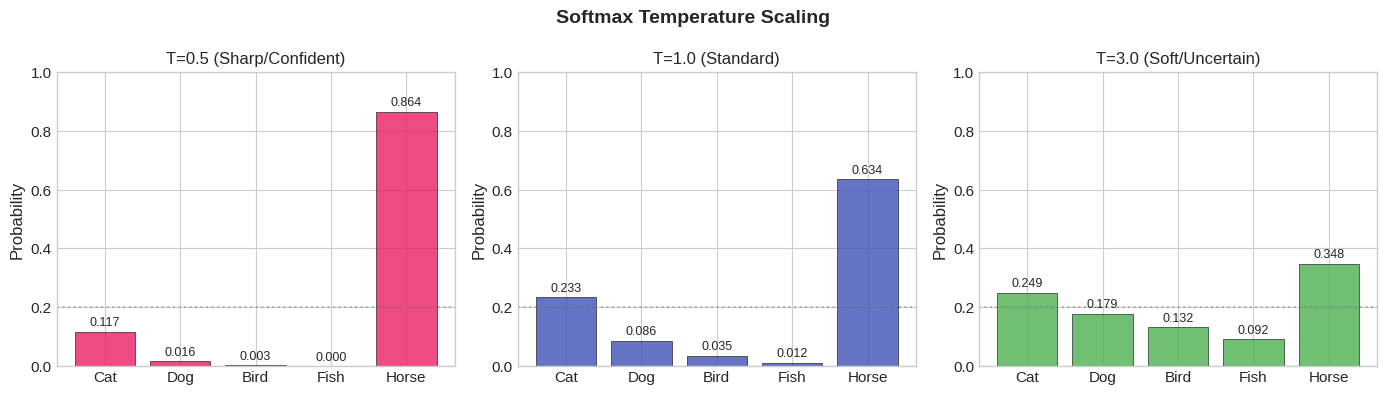


Numerical Stability Demo:
  Logits: [1000 1001 1002]
  Stable softmax: [0.09003057 0.24472847 0.66524096]
  (Without max subtraction, exp(1000) would overflow!)


In [0]:
# --- Softmax Activation Function ---

def softmax(z):
    """Numerically stable softmax."""
    z_shifted = z - np.max(z)  # Numerical stability
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

def softmax_temperature(z, T=1.0):
    """Softmax with temperature scaling."""
    z_scaled = z / T
    z_shifted = z_scaled - np.max(z_scaled)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

# Example: logits for a 5-class classification
np.random.seed(42)
logits = np.array([2.0, 1.0, 0.1, -1.0, 3.0])
classes = ['Cat', 'Dog', 'Bird', 'Fish', 'Horse']

print("Softmax Demo: Multi-class Classification")
print("="*50)
print(f"Raw logits: {logits}")
probs = softmax(logits)
for cls, prob in zip(classes, probs):
    bar = '█' * int(prob * 40)
    print(f"  {cls:6s}: {prob:.4f} |{bar}|")
print(f"  Sum = {np.sum(probs):.6f} (≡ 1.0 always)")

# Temperature scaling visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
temperatures = [0.5, 1.0, 3.0]
titles = ['T=0.5 (Sharp/Confident)', 'T=1.0 (Standard)', 'T=3.0 (Soft/Uncertain)']
colors = ['#E91E63', '#3F51B5', '#4CAF50']

for ax, T, title, color in zip(axes, temperatures, titles, colors):
    probs_T = softmax_temperature(logits, T)
    bars = ax.bar(classes, probs_T, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5, label='Uniform')
    for bar, prob in zip(bars, probs_T):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{prob:.3f}', ha='center', fontsize=9)

plt.suptitle('Softmax Temperature Scaling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Numerical stability demo
print("\nNumerical Stability Demo:")
large_logits = np.array([1000, 1001, 1002])  # Would overflow with naive exp()
print(f"  Logits: {large_logits}")
print(f"  Stable softmax: {softmax(large_logits)}")
print(f"  (Without max subtraction, exp(1000) would overflow!)")

---
## Comprehensive Comparison

The following cells provide a visual comparison of all activation functions and their derivatives, followed by a vanishing gradient analysis.

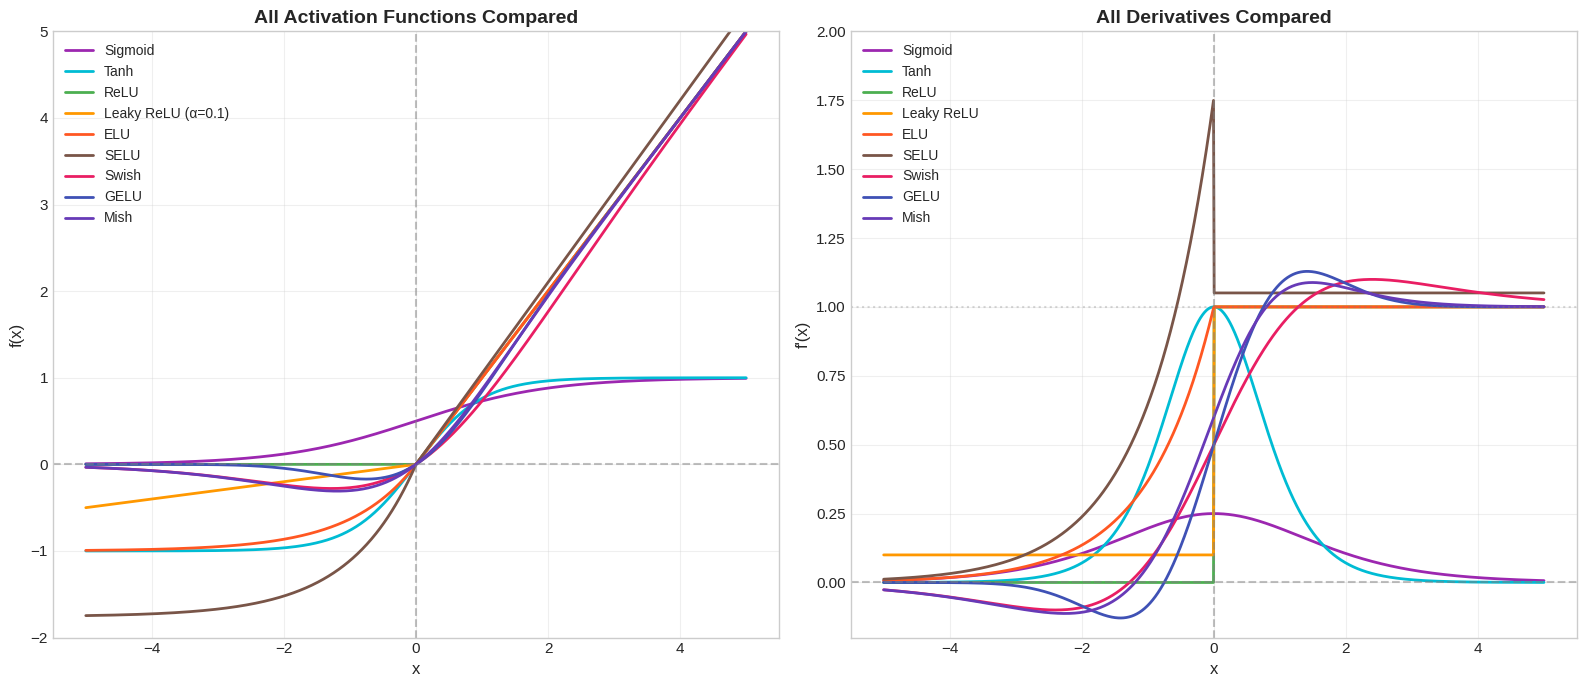

In [0]:
# --- Comprehensive Visual Comparison ---

x = np.linspace(-5, 5, 1000)

# Define all activations
activations = {
    'Sigmoid': (sigmoid(x), '#9C27B0'),
    'Tanh': (tanh(x), '#00BCD4'),
    'ReLU': (relu(x), '#4CAF50'),
    'Leaky ReLU (α=0.1)': (leaky_relu(x, 0.1), '#FF9800'),
    'ELU': (elu(x), '#FF5722'),
    'SELU': (selu(x), '#795548'),
    'Swish': (swish(x), '#E91E63'),
    'GELU': (gelu_exact(x), '#3F51B5'),
    'Mish': (mish(x), '#673AB7'),
}

derivatives = {
    'Sigmoid': (sigmoid_derivative(x), '#9C27B0'),
    'Tanh': (tanh_derivative(x), '#00BCD4'),
    'ReLU': (relu_derivative(x), '#4CAF50'),
    'Leaky ReLU': (leaky_relu_derivative(x, 0.1), '#FF9800'),
    'ELU': (elu_derivative(x), '#FF5722'),
    'SELU': (selu_derivative(x), '#795548'),
    'Swish': (swish_derivative(x), '#E91E63'),
    'GELU': (gelu_derivative(x), '#3F51B5'),
    'Mish': (mish_derivative(x), '#673AB7'),
}

# Create large comparison figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# All activations
for name, (y, color) in activations.items():
    ax1.plot(x, y, color=color, linewidth=2, label=name)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('All Activation Functions Compared', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-2, 5)

# All derivatives
for name, (dy, color) in derivatives.items():
    ax2.plot(x, dy, color=color, linewidth=2, label=name)

ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=1, color='gray', linestyle=':', alpha=0.3)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel("f'(x)", fontsize=12)
ax2.set_title('All Derivatives Compared', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.2, 2.0)

plt.tight_layout()
plt.show()

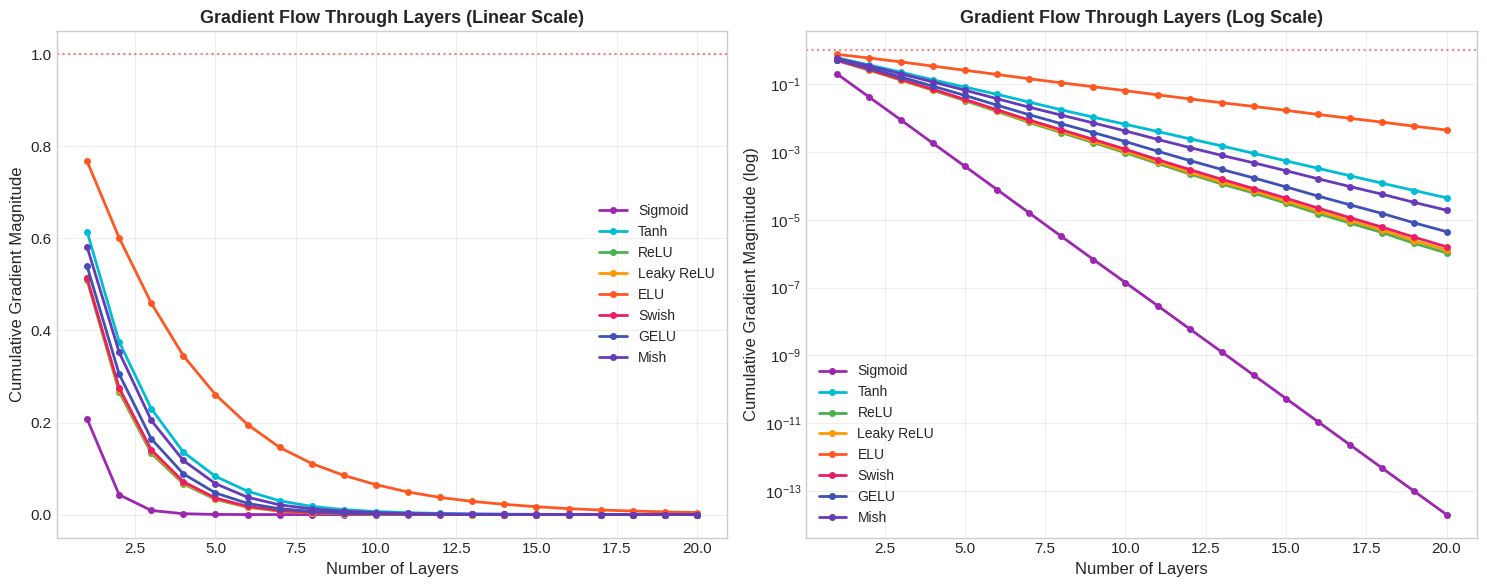


GRADIENT MAGNITUDE AFTER 20 LAYERS
(Higher = Better gradient flow, 1.0 = Ideal)
  Sigmoid        : 2.009071e-14  ❌ VANISHING
  Tanh           : 4.483290e-05  ❌ VANISHING
  ReLU           : 1.062466e-06  ❌ VANISHING
  Leaky ReLU     : 1.293937e-06  ❌ VANISHING
  ELU            : 4.487881e-03  ✅ HEALTHY
  Swish          : 1.608111e-06  ❌ VANISHING
  GELU           : 4.484584e-06  ❌ VANISHING
  Mish           : 1.932333e-05  ❌ VANISHING


In [0]:
# --- Vanishing Gradient Analysis ---
# Simulate gradient flow through N layers for each activation function

def simulate_gradient_flow(activation_derivative_fn, n_layers=20, n_samples=1000):
    """Simulate how gradients decay through multiple layers."""
    np.random.seed(42)
    # Sample pre-activation values from standard normal (typical after initialization)
    cumulative_gradients = []
    
    for layer in range(1, n_layers + 1):
        # Pre-activations drawn from N(0,1)
        z = np.random.randn(n_samples)
        local_grads = activation_derivative_fn(z)
        
        if layer == 1:
            cum_grad = np.mean(np.abs(local_grads))
        else:
            cum_grad = cumulative_gradients[-1] * np.mean(np.abs(local_grads))
        cumulative_gradients.append(cum_grad)
    
    return cumulative_gradients

# Compute gradient decay for each activation
n_layers = 20
activation_derivs = {
    'Sigmoid': sigmoid_derivative,
    'Tanh': tanh_derivative,
    'ReLU': relu_derivative,
    'Leaky ReLU': lambda x: leaky_relu_derivative(x, 0.01),
    'ELU': elu_derivative,
    'Swish': swish_derivative,
    'GELU': gelu_derivative,
    'Mish': mish_derivative,
}

colors = ['#9C27B0', '#00BCD4', '#4CAF50', '#FF9800', '#FF5722', '#E91E63', '#3F51B5', '#673AB7']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Linear scale
for (name, deriv_fn), color in zip(activation_derivs.items(), colors):
    grads = simulate_gradient_flow(deriv_fn, n_layers)
    ax1.plot(range(1, n_layers+1), grads, color=color, linewidth=2, marker='o', 
             markersize=4, label=name)

ax1.set_xlabel('Number of Layers', fontsize=12)
ax1.set_ylabel('Cumulative Gradient Magnitude', fontsize=12)
ax1.set_title('Gradient Flow Through Layers (Linear Scale)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='red', linestyle=':', alpha=0.5, label='Ideal (=1)')

# Log scale (shows vanishing more clearly)
for (name, deriv_fn), color in zip(activation_derivs.items(), colors):
    grads = simulate_gradient_flow(deriv_fn, n_layers)
    ax2.semilogy(range(1, n_layers+1), grads, color=color, linewidth=2, marker='o', 
                 markersize=4, label=name)

ax2.set_xlabel('Number of Layers', fontsize=12)
ax2.set_ylabel('Cumulative Gradient Magnitude (log)', fontsize=12)
ax2.set_title('Gradient Flow Through Layers (Log Scale)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1, color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Print final gradient magnitudes
print("\n" + "="*60)
print("GRADIENT MAGNITUDE AFTER 20 LAYERS")
print("(Higher = Better gradient flow, 1.0 = Ideal)")
print("="*60)
for (name, deriv_fn), color in zip(activation_derivs.items(), colors):
    grads = simulate_gradient_flow(deriv_fn, n_layers)
    final = grads[-1]
    if final < 1e-4:
        status = "❌ VANISHING"
    elif final > 10:
        status = "⚠️ EXPLODING"
    else:
        status = "✅ HEALTHY"
    print(f"  {name:15s}: {final:.6e}  {status}")

In [0]:
# --- Practical Implementation with PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Activation Functions in PyTorch")
print("="*60)

# Create sample input tensor
x = torch.linspace(-3, 3, 7)
print(f"\nInput tensor: {x.numpy()}")
print("-"*60)

# Demonstrate all activations in PyTorch
activations_torch = {
    'Sigmoid': torch.sigmoid(x),
    'Tanh': torch.tanh(x),
    'ReLU': F.relu(x),
    'LeakyReLU(0.01)': F.leaky_relu(x, 0.01),
    'ELU(α=1.0)': F.elu(x, alpha=1.0),
    'SELU': F.selu(x),
    'SiLU (Swish)': F.silu(x),
    'GELU': F.gelu(x),
    'Mish': F.mish(x),
    'Softmax': F.softmax(x, dim=0),
}

for name, output in activations_torch.items():
    print(f"  {name:18s}: {output.numpy().round(4)}")

print("\n" + "="*60)
print("Using Activations as nn.Module Layers:")
print("="*60)

# Example: Building a model with different activations
class FlexibleMLP(nn.Module):
    """MLP that demonstrates different activation choices."""
    
    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        
        # Choose activation
        activation_map = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.01),
            'elu': nn.ELU(alpha=1.0),
            'selu': nn.SELU(),
            'swish': nn.SiLU(),
            'gelu': nn.GELU(),
            'mish': nn.Mish(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
        }
        self.activation = activation_map.get(activation, nn.ReLU())
        self.output_activation = nn.Softmax(dim=-1)
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.output_activation(self.fc3(x))
        return x

# Instantiate models with different activations
print("\n  Model architectures with different activations:")
for act_name in ['relu', 'gelu', 'swish', 'mish', 'selu']:
    model = FlexibleMLP(784, 256, 10, activation=act_name)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"    {act_name:12s}: {n_params:,} parameters")

# Quick forward pass test
model = FlexibleMLP(784, 256, 10, activation='gelu')
sample_input = torch.randn(32, 784)  # Batch of 32, MNIST-sized
output = model(sample_input)
print(f"\n  Forward pass test (GELU model):")
print(f"    Input shape:  {sample_input.shape}")
print(f"    Output shape: {output.shape}")
print(f"    Output sums to 1: {output[0].sum().item():.6f} ✓")
print(f"    Prediction:   class {output[0].argmax().item()}")

Activation Functions in PyTorch

Input tensor: [-3. -2. -1.  0.  1.  2.  3.]
------------------------------------------------------------
  Sigmoid           : [0.0474 0.1192 0.2689 0.5    0.7311 0.8808 0.9526]
  Tanh              : [-0.9951 -0.964  -0.7616  0.      0.7616  0.964   0.9951]
  ReLU              : [0. 0. 0. 0. 1. 2. 3.]
  LeakyReLU(0.01)   : [-0.03 -0.02 -0.01  0.    1.    2.    3.  ]
  ELU(α=1.0)        : [-0.9502 -0.8647 -0.6321  0.      1.      2.      3.    ]
  SELU              : [-1.6706 -1.5202 -1.1113  0.      1.0507  2.1014  3.1521]
  SiLU (Swish)      : [-0.1423 -0.2384 -0.2689  0.      0.7311  1.7616  2.8577]
  GELU              : [-0.004  -0.0455 -0.1587  0.      0.8413  1.9545  2.996 ]
  Mish              : [-0.1456 -0.2525 -0.3034  0.      0.8651  1.944   2.9865]
  Softmax           : [0.0016 0.0043 0.0116 0.0315 0.0856 0.2328 0.6327]

Using Activations as nn.Module Layers:

  Model architectures with different activations:
    relu        : 269,322 paramete

Training Comparison Experiment
  Dataset: 500 samples, 20 features, 5 classes
  Architecture: Input(20) → Hidden(64) → Hidden(64) → Output(5)
  Training: 100 epochs, Adam optimizer, lr=0.01
------------------------------------------------------------
  relu         | Final Loss: 1.2419 | Accuracy: 66.2%
  leaky_relu   | Final Loss: 1.2106 | Accuracy: 69.0%
  elu          | Final Loss: 0.9315 | Accuracy: 97.4%
  swish        | Final Loss: 0.9651 | Accuracy: 93.8%
  gelu         | Final Loss: 0.9500 | Accuracy: 95.4%
  mish         | Final Loss: 0.9307 | Accuracy: 97.4%
  tanh         | Final Loss: 0.9238 | Accuracy: 98.2%
  sigmoid      | Final Loss: 1.2428 | Accuracy: 66.2%


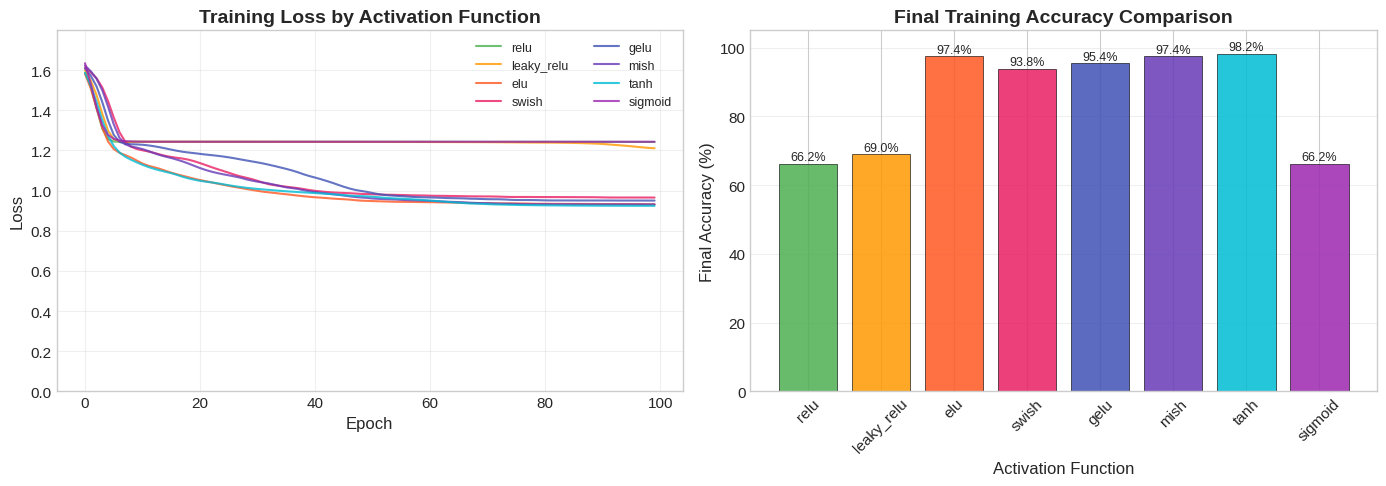


✅ Modern activations (Swish, GELU, Mish) typically converge faster and achieve
   comparable or better accuracy than ReLU on non-trivial problems.


In [0]:
# --- Training Comparison: How Activation Choice Affects Learning ---

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def train_model(activation_name, X_train, y_train, epochs=100, hidden_dim=64, lr=0.01):
    """Train a simple model with given activation and return loss history."""
    input_dim = X_train.shape[1]
    output_dim = len(torch.unique(y_train))
    
    model = FlexibleMLP(input_dim, hidden_dim, output_dim, activation=activation_name)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    # Final accuracy
    with torch.no_grad():
        preds = model(X_train).argmax(dim=1)
        accuracy = (preds == y_train).float().mean().item()
    
    return losses, accuracy

# Create a synthetic classification dataset
torch.manual_seed(42)
n_samples = 500
n_features = 20
n_classes = 5

# Generate non-linearly separable data
X_train = torch.randn(n_samples, n_features)
# Create labels based on non-linear combination
y_train = (X_train[:, :5].sum(dim=1) + X_train[:, 5:10].prod(dim=1)).clamp(0, n_classes-1).long()
y_train = y_train % n_classes

print("Training Comparison Experiment")
print("="*60)
print(f"  Dataset: {n_samples} samples, {n_features} features, {n_classes} classes")
print(f"  Architecture: Input(20) → Hidden(64) → Hidden(64) → Output(5)")
print(f"  Training: 100 epochs, Adam optimizer, lr=0.01")
print("-"*60)

# Train with different activations
activation_names = ['relu', 'leaky_relu', 'elu', 'swish', 'gelu', 'mish', 'tanh', 'sigmoid']
results = {}

for act in activation_names:
    losses, accuracy = train_model(act, X_train, y_train)
    results[act] = {'losses': losses, 'accuracy': accuracy}
    print(f"  {act:12s} | Final Loss: {losses[-1]:.4f} | Accuracy: {accuracy*100:.1f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {
    'relu': '#4CAF50', 'leaky_relu': '#FF9800', 'elu': '#FF5722',
    'swish': '#E91E63', 'gelu': '#3F51B5', 'mish': '#673AB7',
    'tanh': '#00BCD4', 'sigmoid': '#9C27B0'
}

for act in activation_names:
    color = colors_map[act]
    ax1.plot(results[act]['losses'], color=color, linewidth=1.5, label=act, alpha=0.8)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss by Activation Function', fontweight='bold')
ax1.legend(fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(results['sigmoid']['losses'][0], results['tanh']['losses'][0]) * 1.1)

# Bar chart of final accuracies
accuracies = [results[act]['accuracy'] * 100 for act in activation_names]
bars = ax2.bar(activation_names, accuracies, 
               color=[colors_map[act] for act in activation_names],
               edgecolor='black', linewidth=0.5, alpha=0.85)
ax2.set_xlabel('Activation Function')
ax2.set_ylabel('Final Accuracy (%)')
ax2.set_title('Final Training Accuracy Comparison', fontweight='bold')
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for bar, acc in zip(bars, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n\u2705 Modern activations (Swish, GELU, Mish) typically converge faster and achieve")
print("   comparable or better accuracy than ReLU on non-trivial problems.")

---
## Summary: Quick Reference & Selection Guide

### Activation Function Properties at a Glance

| Activation | Range | Zero-Centered | Vanishing Gradient | Dying Neurons | Computational Cost |
| --- | --- | --- | --- | --- | --- |
| **Sigmoid** | $$(0, 1)$$ | No | Severe | No | Medium |
| **Tanh** | $$(-1, 1)$$ | Yes | Moderate | No | Medium |
| **ReLU** | $$[0, \infty)$$ | No | None (x>0) | Yes (critical) | Very Low |
| **Leaky ReLU** | $$(-\infty, \infty)$$ | Approx. | None | No | Very Low |
| **ELU** | $$[-\alpha, \infty)$$ | Approx. | Minimal | No | Medium |
| **SELU** | $$[-1.76, \infty)$$ | Yes (self-norm) | None | No | Medium |
| **Swish** | $$[-0.28, \infty)$$ | Approx. | None | No | Medium-High |
| **GELU** | $$[-0.17, \infty)$$ | Approx. | None | No | Medium-High |
| **Mish** | $$[-0.31, \infty)$$ | Approx. | None | No | High |
| **Softmax** | $$(0, 1)^K$$ | N/A | N/A | N/A | High |

### Decision Flowchart

```
Q: What layer is this?
├── Output layer (binary classification) → Sigmoid
├── Output layer (multi-class) → Softmax
├── Output layer (regression, bounded) → Tanh or Sigmoid
└── Hidden layer:
    ├── Transformer / NLP → GELU
    ├── CNN / EfficientNet → Swish (SiLU)
    ├── Object Detection (YOLO) → Mish
    ├── Deep MLP (no skip connections) → SELU + Lecun init
    ├── RNN/LSTM cell state → Tanh
    ├── GAN discriminator → Leaky ReLU
    └── General / default → ReLU (with He init)
        └── If dying ReLU observed → Leaky ReLU or ELU
```

### Historical Evolution

| Era | Year | Activation | Milestone |
| --- | --- | --- | --- |
| Classical | <2010 | Sigmoid, Tanh | Shallow networks, limited depth |
| Deep Learning Revolution | 2012 | **ReLU** | AlexNet, enabled deep CNNs |
| Fixing ReLU | 2013-2016 | Leaky ReLU, ELU, SELU | Addressed dying neurons |
| Modern (Searched/Designed) | 2017-2019 | **Swish, GELU, Mish** | Automated discovery, Transformers |
| Current Default | 2020+ | **GELU** (NLP), **SiLU** (Vision) | Architecture-specific choices |

### Key Takeaways

1. **Never use Sigmoid/Tanh in hidden layers** of deep networks (>3 layers) — vanishing gradients will cripple training
2. **ReLU remains the safe default** for most architectures — simple, fast, effective
3. **GELU for Transformers** — it's the standard and optimized in all major frameworks
4. **Swish/SiLU for deep CNNs** — marginal but consistent gains over ReLU in deep architectures
5. **Always pair activation choice with proper initialization**: He init for ReLU variants, Lecun for SELU, Xavier for Sigmoid/Tanh
6. **The choice matters less than you think** once you have BatchNorm, residual connections, and proper learning rate scheduling — architecture design dominates over activation choice

In [0]:
# --- Final Summary: Recommended Initialization Pairings ---
import pandas as pd

summary_data = {
    'Activation': ['Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU', 'ELU', 'SELU', 'Swish/SiLU', 'GELU', 'Mish', 'Softmax'],
    'Recommended Init': ['Xavier/Glorot', 'Xavier/Glorot', 'He (Kaiming)', 'He (Kaiming)', 
                         'He (Kaiming)', 'Lecun Normal', 'He (Kaiming)', 'He (Kaiming)', 'He (Kaiming)', 'Xavier/Glorot'],
    'Best Architecture': ['Output (binary)', 'RNN/LSTM', 'CNN/MLP', 'GAN/Deep CNN', 
                          'Autoencoder', 'Deep MLP only', 'EfficientNet/MobileNet', 'Transformer/BERT/GPT', 'YOLOv4/v5', 'Output (multi-class)'],
    'Vanishing Gradient': ['❌ Severe', '⚠️ Moderate', '✅ None*', '✅ None', 
                           '✅ Minimal', '✅ None', '✅ None', '✅ None', '✅ None', 'N/A'],
    'Year Introduced': [1943, 1986, 2010, 2013, 2016, 2017, 2017, 2016, 2019, 1959],
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("ACTIVATION FUNCTION QUICK REFERENCE GUIDE")
print("="*80)
display(df_summary)
print("\n* ReLU has no vanishing gradient for x>0, but suffers from dying neurons (zero gradient for x<0)")
print("\n" + "🎯 " + "Remember: The activation function is ONE piece of the puzzle.")
print("   Architecture, normalization, residual connections, and learning rate")
print("   schedule often have a larger impact on final performance.")


ACTIVATION FUNCTION QUICK REFERENCE GUIDE


Activation,Recommended Init,Best Architecture,Vanishing Gradient,Year Introduced
Sigmoid,Xavier/Glorot,Output (binary),❌ Severe,1943
Tanh,Xavier/Glorot,RNN/LSTM,⚠️ Moderate,1986
ReLU,He (Kaiming),CNN/MLP,✅ None*,2010
Leaky ReLU,He (Kaiming),GAN/Deep CNN,✅ None,2013
ELU,He (Kaiming),Autoencoder,✅ Minimal,2016
SELU,Lecun Normal,Deep MLP only,✅ None,2017
Swish/SiLU,He (Kaiming),EfficientNet/MobileNet,✅ None,2017
GELU,He (Kaiming),Transformer/BERT/GPT,✅ None,2016
Mish,He (Kaiming),YOLOv4/v5,✅ None,2019
Softmax,Xavier/Glorot,Output (multi-class),N/A,1959



* ReLU has no vanishing gradient for x>0, but suffers from dying neurons (zero gradient for x<0)

🎯 Remember: The activation function is ONE piece of the puzzle.
   Architecture, normalization, residual connections, and learning rate
   schedule often have a larger impact on final performance.
